<a href="https://colab.research.google.com/github/Aarush-Yadavv/Mircosoft_Training/blob/main/Logistic_Regression_Pass_Fail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/Pass-Fail Data.csv")

In [ ]:
data.isnull().sum()

,0
student_id,0
attendance_pct,0
homework_pct,0
midterm_score,0
study_hours_per_week,0
pass,0


In [ ]:
data.describe()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


In [ ]:
data.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [ ]:
data.tail()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
95,96,89,92,94,14,1
96,97,79,77,75,8,1
97,98,55,56,58,5,0
98,99,91,90,88,12,1
99,100,52,50,53,4,0


In [ ]:
data.shape

(100, 6)

In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
95,False
96,False
97,False
98,False


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB
None


In [ ]:
print(data['midterm_score'].mean())
print(data['attendance_pct'].mean())
print(data['study_hours_per_week'].mean())

68.78
69.52
7.28


In [ ]:
corr = data.corr()
corr

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
student_id,1.000000,0.001519,-0.002609,0.013508,-0.006730,-0.036771
attendance_pct,0.001519,1.000000,0.985897,0.963359,0.936850,0.873757
homework_pct,-0.002609,0.985897,1.000000,0.988604,0.966403,0.869662
midterm_score,0.013508,0.963359,0.988604,1.000000,0.986944,0.839442
study_hours_per_week,-0.006730,0.936850,0.966403,0.986944,1.000000,0.811285
pass,-0.036771,0.873757,0.869662,0.839442,0.811285,1.000000


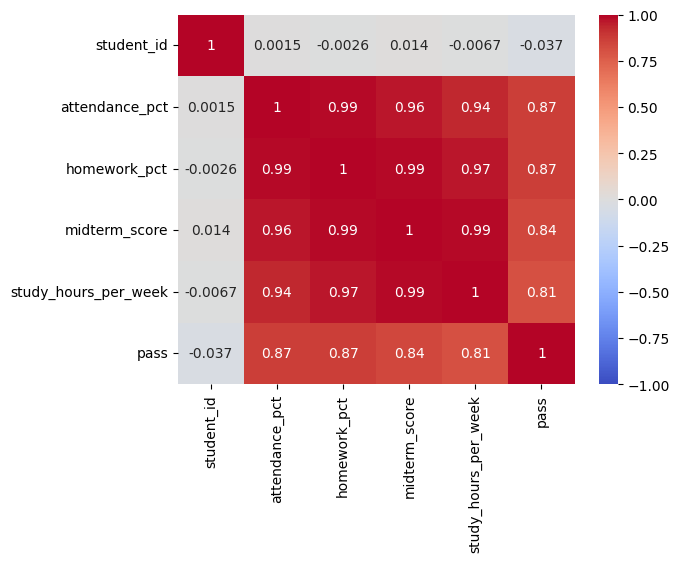

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

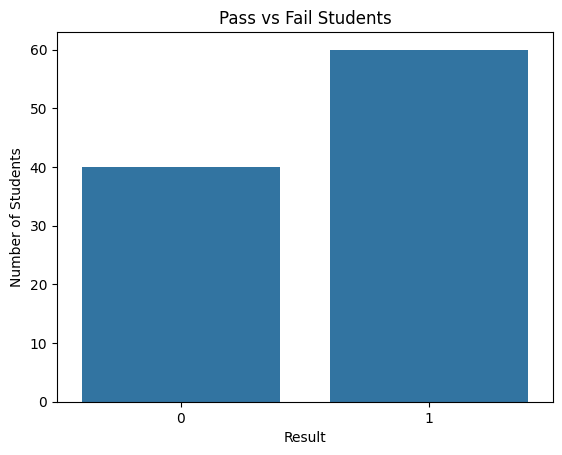

In [ ]:
sns.countplot(x="pass", data=data)
plt.title("Pass vs Fail Students")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
data.shape

(100, 6)

In [ ]:
X = data.drop(["student_id","pass"],axis=1)

y = data["pass"]

In [ ]:
print("Features:")
print(X.head())

Features:
   attendance_pct  homework_pct  midterm_score  study_hours_per_week
0              95            92             88                    12
1              88            85             79                    10
2              60            55             58                     4
3              72            70             65                     6
4              40            45             50                     3


In [ ]:
print("Target:")
print(y.head())

Target:
0    1
1    1
2    0
3    1
4    0
Name: pass, dtype: int64


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (80, 4)
Testing Data Shape: (20, 4)


In [ ]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (80, 4)
Testing Features Shape: (20, 4)
Training Target Shape: (80,)
Testing Target Shape: (20,)


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
# Train the model using training data

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predict results for test data

y_pred = model.predict(X_test)

print(y_pred)

[1 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1]


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
83,1,1
53,1,1
70,0,0
45,0,0
44,1,1
39,1,1
22,0,0
80,0,0
10,0,0
0,1,1


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
# Import evaluation metrics

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 8  0]
 [ 0 12]]


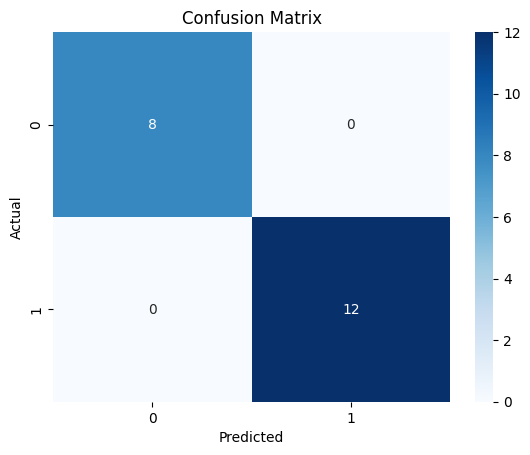

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
# Final Model Performance Summary

print("Model Accuracy :", accuracy_score(y_test, y_pred) * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy : 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
# New student data
new_student = [[90, 85, 80, 10]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")

Student is likely to PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

new_student = pd.DataFrame({
    "attendance_pct": [90],
    "homework_pct": [85],
    "midterm_s#core": [80],
    "study_hours_per_week": [10]
})

prediction = model.predict(new_student)

print(prediction)

[1]


In [ ]:
prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")

Student is likely to PASS


In [ ]:
#for probability

probability = model.predict_proba(new_student)

print("Probability of Fail :", round(probability[0][0]*100,2), "%")
print("Probability of Pass :", round(probability[0][1]*100,2), "%")

Probability of Fail : 0.0 %
Probability of Pass : 100.0 %
